In [1]:
import scanpy as sc
import wot
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import math
import ipywidgets as widgets

In [2]:
#Figure settings
sc.set_figure_params(dpi_save = 350)
mpl.rcParams['figure.figsize'] = (4, 4) #1:1 plot ratio
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14) 
mpl.rc('axes', labelsize=16) 
mpl.rc('axes', labelsize=16)
mpl.rcParams['pdf.fonttype'] = 42 #Ensures readable fonts in illustrator
mpl.rcParams['ps.fonttype'] = 42
plt.rc('axes', axisbelow=True) #Ensure that gridlines are behind points
mplparams = mpl.rcParams.copy()

Read data

In [3]:
adata_temp = sc.read('./data/Rep1_Merged_v2_h5Seurat.h5ad')

/usr/local/lib/python3.8/dist-packages/anndata/compat/__init__.py:180: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [4]:
adata_temp = adata_temp[~(adata_temp.obs.seurat_clusters == 3)].copy()

In [5]:
adata_temp

AnnData object with n_obs × n_vars = 7202 × 14812
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'CellType', 'percent.mt', 'sample_type', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.3', 'seurat_clusters', 'timePoint'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    varm: 'HARMONY', 'PCs'
    obsp: 'distances'

In [6]:
adata = sc.AnnData(adata_temp.raw.X)

In [7]:
adata.obs_names = adata_temp.obs_names
adata.obs = adata_temp.obs
adata.obsm['X_pca'] = adata_temp.obsm['X_harmony']

In [8]:
adata.obs['clu_cat'] = adata.obs['seurat_clusters'].astype('category')
adata.var_names = adata_temp.raw.var['_index']

In [9]:
wt_ko = np.array(['KO' for i in range(adata.shape[0])],dtype = 'str')
vec_wt = adata.obs.sample_type.str.startswith('WT')
wt_ko[vec_wt] = 'WT'

adata.obs['sample_wt_ko'] = wt_ko

In [10]:
adata.obs['clu_type'] = 'clu_' + adata.obs.seurat_clusters.astype('str') + '_type' + adata.obs.sample_wt_ko.astype('str')

In [11]:
adata.obs['clu_cat'] = adata.obs['seurat_clusters'].astype('category')

In [12]:
vec = np.array([-1 for i in range(adata.shape[0])],dtype = 'int')
for i in range(adata.shape[0]):
    name = adata.obs['timePoint'][i]
    vec[i] = int(name[3:-3])

In [13]:
adata.obs['day'] = vec

Umap

In [14]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

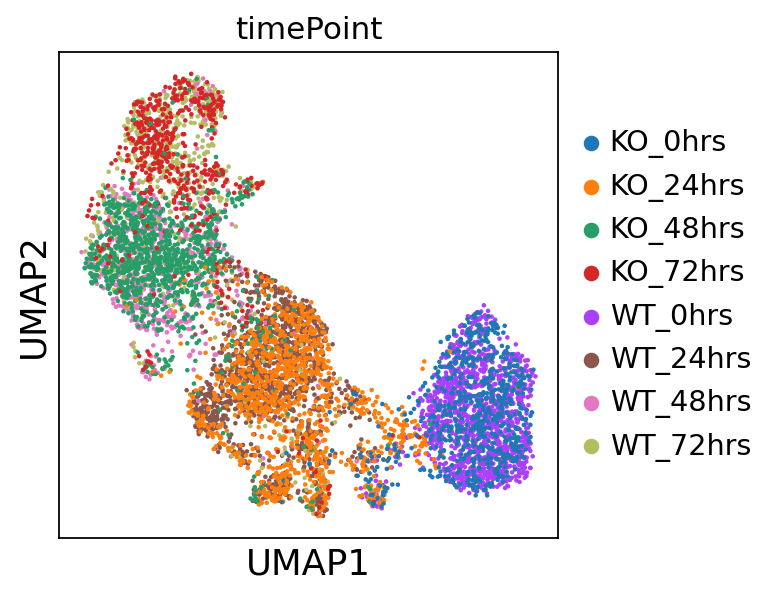

In [15]:
sc.pl.umap(adata,color = 'timePoint')

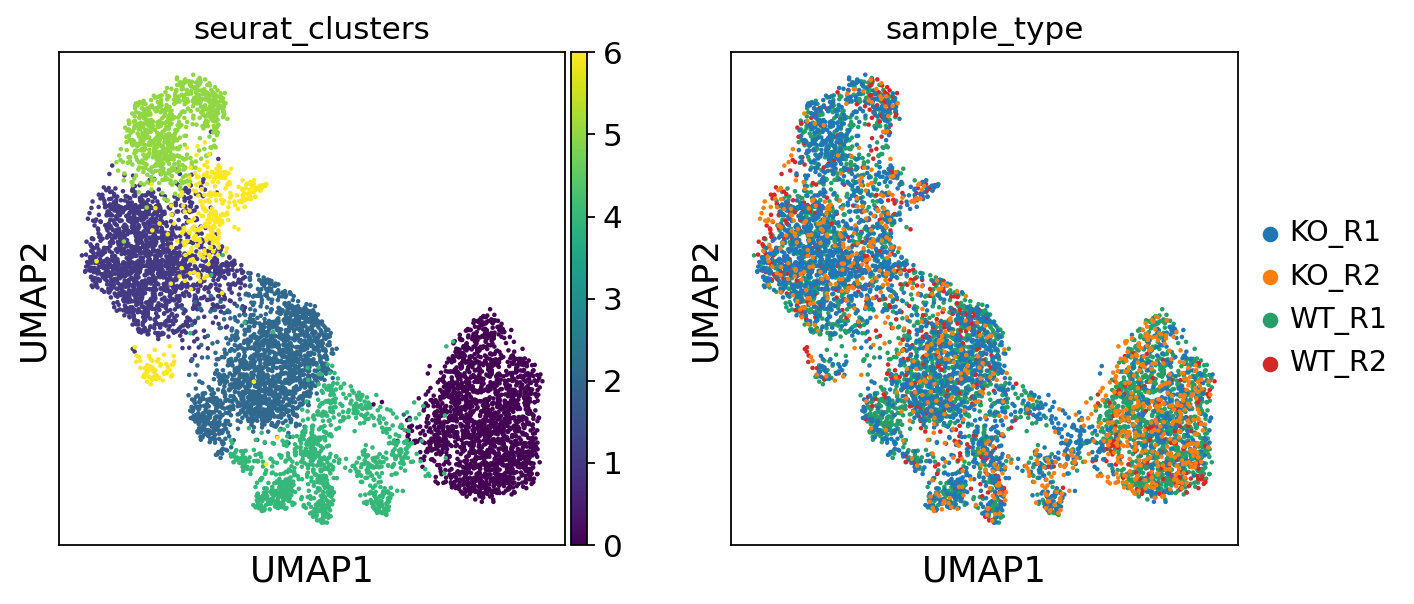

In [16]:
sc.pl.umap(adata,color = ['seurat_clusters','sample_type'])

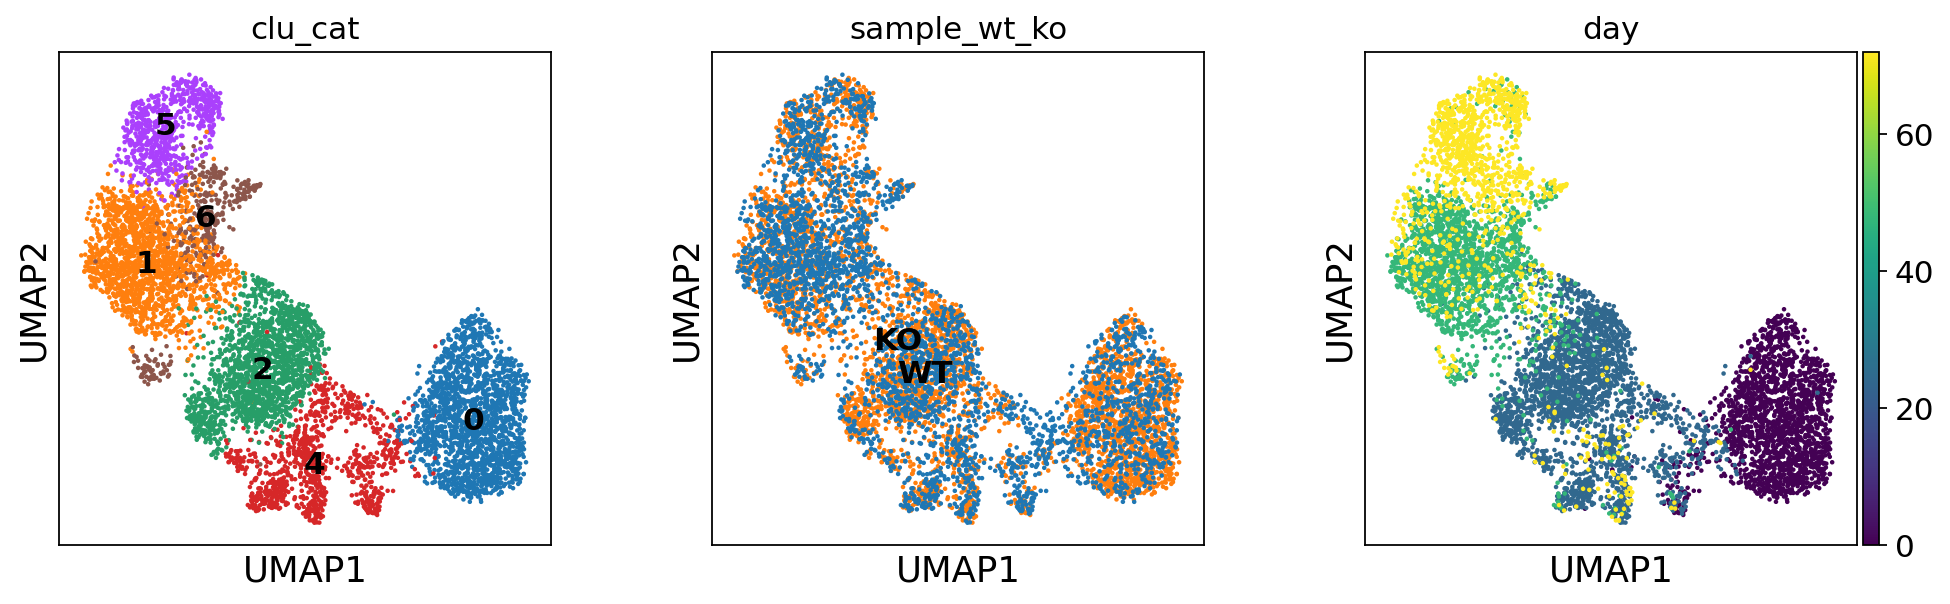

In [17]:
sc.pl.umap(adata,color = ['clu_cat','sample_wt_ko','day'],legend_loc='on data')

WOT on knock out

In [18]:
adata_wot = sc.AnnData(adata[~vec_wt].obsm['X_pca'])
adata_wot.obs_names = adata[~vec_wt].obs_names.copy()
adata_wot.obs = adata[~vec_wt].obs.copy()
adata_wot.obs['day_t'] = adata[~vec_wt].obs.timePoint.copy()
adata_wot.obs['x'] = adata[~vec_wt].obsm['X_umap'][:,0].copy()
adata_wot.obs['y'] = adata[~vec_wt].obsm['X_umap'][:,1].copy()

In [19]:
adata_wot

AnnData object with n_obs × n_vars = 3321 × 50
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'CellType', 'percent.mt', 'sample_type', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.3', 'seurat_clusters', 'timePoint', 'clu_cat', 'sample_wt_ko', 'clu_type', 'day', 'day_t', 'x', 'y'

Text(0.5, 1.0, 'Day')

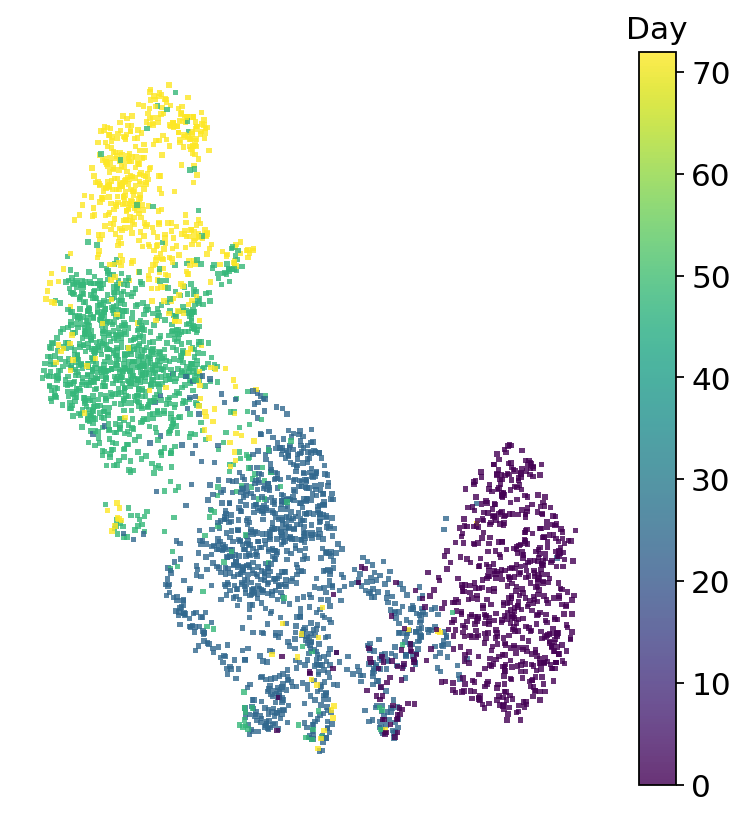

In [20]:
unique_days = adata_wot.obs['day'].unique()
unique_days = unique_days[np.isnan(unique_days) == False]

figure = plt.figure(figsize=(5, 5))
plt.axis('off')
plt.tight_layout()
plt.scatter(adata_wot.obs['x'], adata_wot.obs['y'],c=adata_wot.obs['day'],
               s=6, marker=',', edgecolors='none', alpha=0.8)
cb = plt.colorbar()
cb.ax.set_title('Day')

In [21]:
ot_model = wot.ot.OTModel(adata_wot,local_pca = 0, epsilon = 0.2, lambda1 = 1,lambda2 = 50, growth_iters = 3)

In [22]:
ot_model.compute_all_transport_maps(tmap_out='./data/tmap_ko/tmaps')

In [23]:
tmap_model = wot.tmap.TransportMapModel.from_directory('./data/tmap_ko/')

In [53]:
dicts = {}
keys = np.unique(adata.obs.clu_type)
 
for i in keys:
    

    dicts[i] = list(adata[adata.obs.clu_type == i].obs_names)

In [54]:
populations = tmap_model.population_from_cell_sets(dicts, at_time=72)

trajectory_ds = tmap_model.trajectories(populations)

trajectory_ds.obs = trajectory_ds.obs.join(adata_wot.obs[['x','y']])

# Visualize trajectories
trajectory_dropdown = widgets.Dropdown(
    options=trajectory_ds.var.index,
    description='Trajectory:'
)

interactive(children=(Dropdown(description='Trajectory:', index=5, options=('clu_0_typeKO', 'clu_1_typeKO', 'c…

<function __main__.update_trajectory_vis(name)>

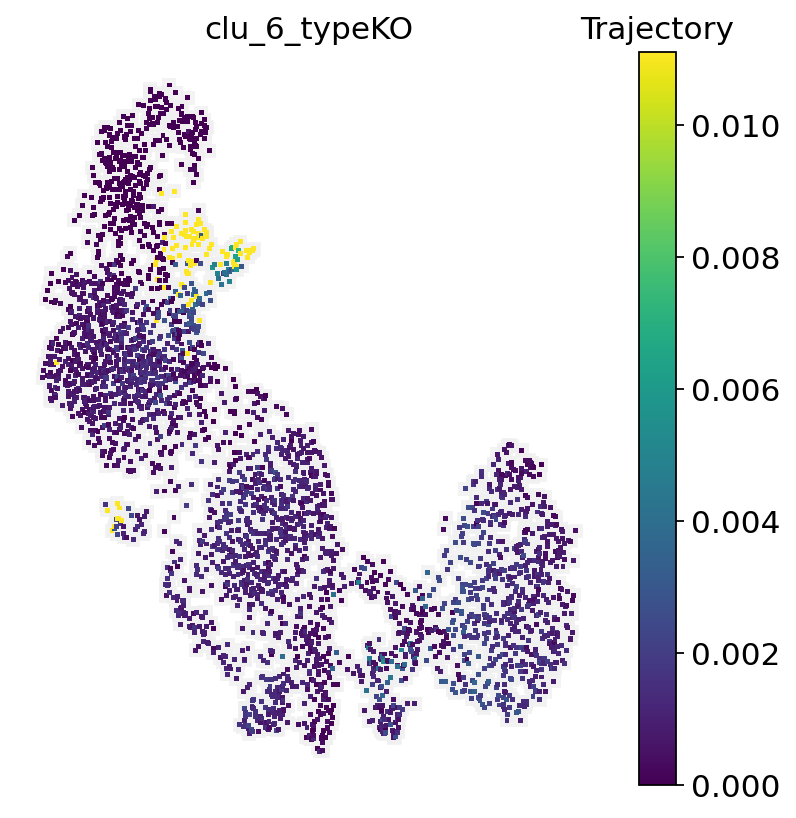

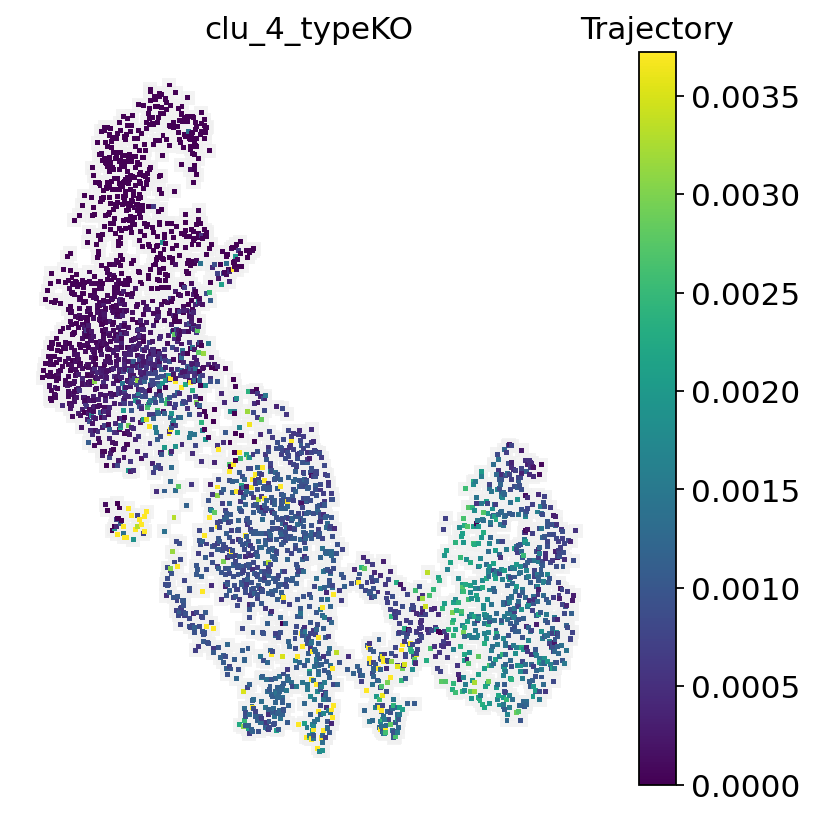

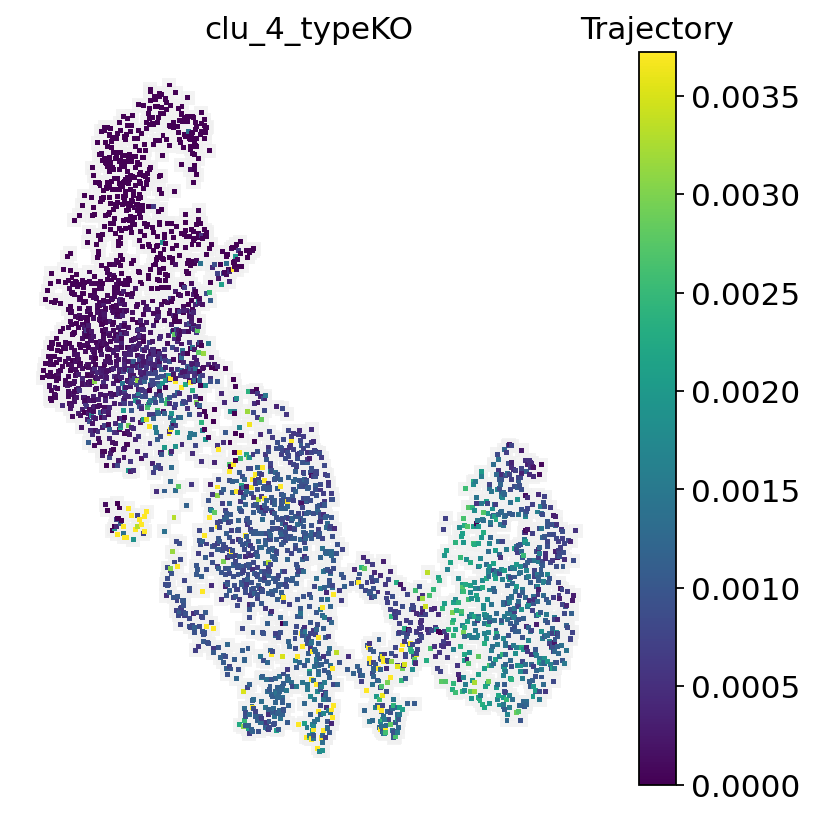

In [59]:
def update_trajectory_vis(name):
    figure = plt.figure(figsize=(5, 5))
    plt.axis('off')
    plt.tight_layout()
    plt.title(name)
    plt.scatter(adata_wot.obs['x'], adata_wot.obs['y'], c='#f0f0f0',
                   s=40, marker=',', edgecolors='none', alpha=0.8)
    binned_df = trajectory_ds.obs.copy()
    binned_df['values'] = trajectory_ds[:, name].X
    binned_df = binned_df.groupby(['x', 'y'], as_index=False).sum()
    plt.scatter(binned_df['x'], binned_df['y'], c=binned_df['values'],
                   s=5, marker=',', edgecolors='none', vmax=binned_df['values'].quantile(0.975))
    plt.colorbar().ax.set_title('Trajectory')
    
widgets.interact(update_trajectory_vis, name=trajectory_dropdown)

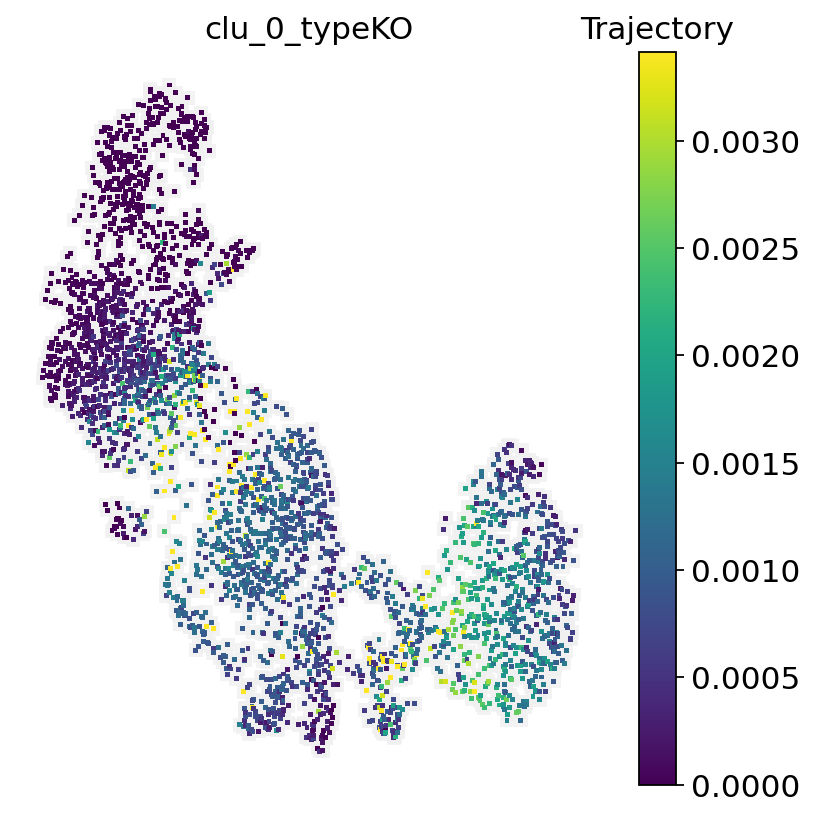

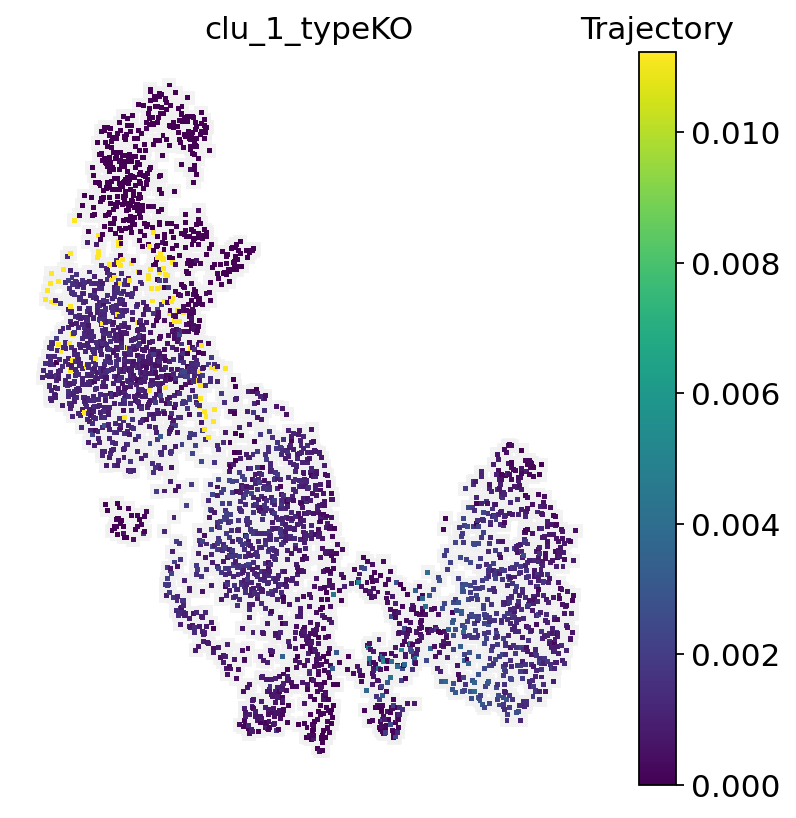

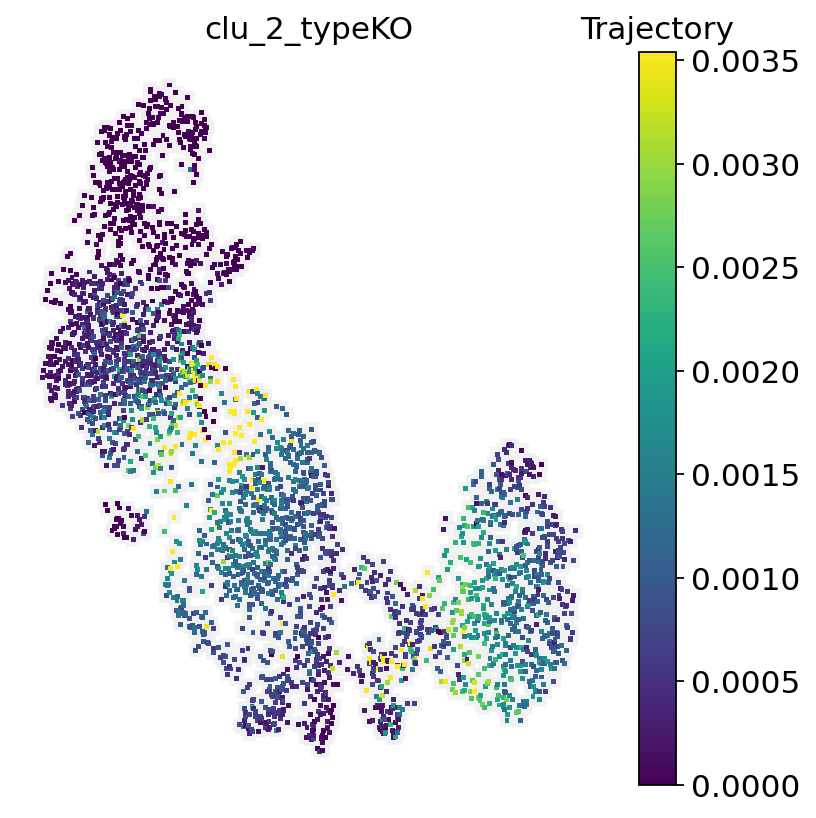

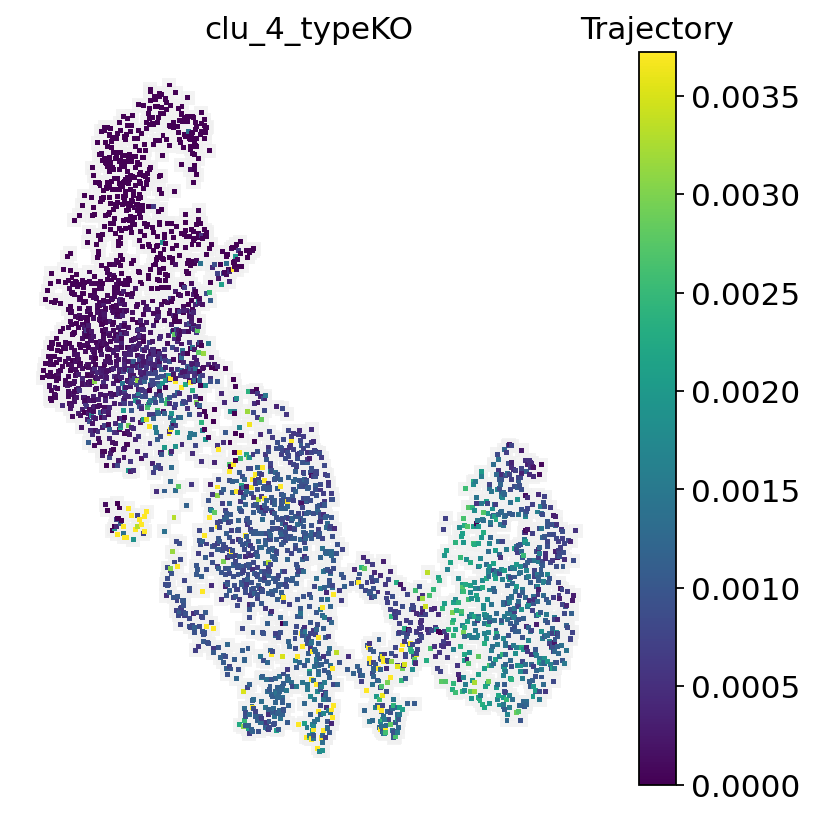

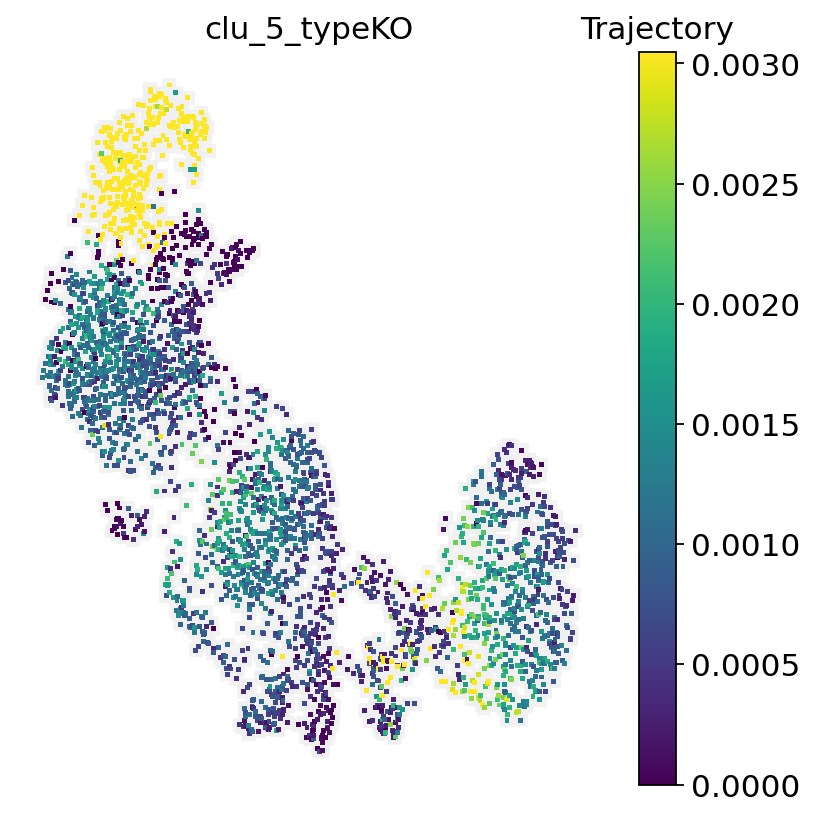

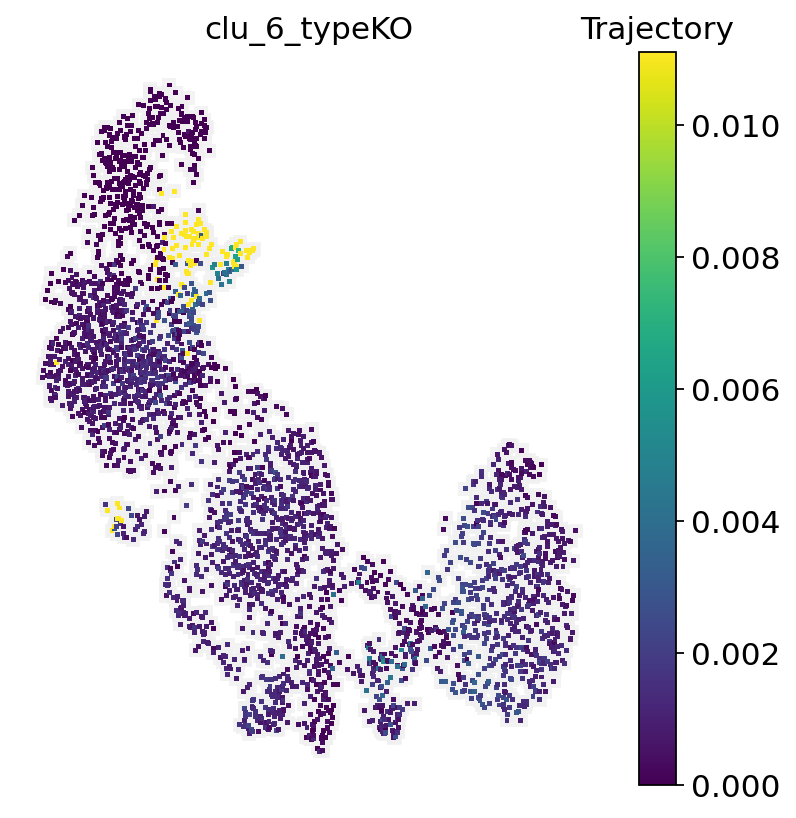

In [61]:
for name in trajectory_ds.var.index:
    figure = plt.figure(figsize=(5, 5))
    plt.axis('off')
    plt.tight_layout()
    plt.title(name)
    plt.scatter(adata_wot.obs['x'], adata_wot.obs['y'], c='#f0f0f0',
                   s=40, marker=',', edgecolors='none', alpha=0.8)
    binned_df = trajectory_ds.obs.copy()
    binned_df['values'] = trajectory_ds[:, name].X
    binned_df = binned_df.groupby(['x', 'y'], as_index=False).sum()
    plt.scatter(binned_df['x'], binned_df['y'], c=binned_df['values'],
                   s=5, marker=',', edgecolors='none', vmax=binned_df['values'].quantile(0.975))
    plt.colorbar().ax.set_title('Trajectory')
    
    figure.savefig('./figures/trajectory_' + name + '.png')




In [62]:
#Compute trends for all genes
trajectory_trends = wot.tmap.trajectory_trends_from_trajectory(trajectory_ds, adata)

# Save each trajectory in a separate file
for i in range(len(trajectory_trends)):
    wot.io.write_dataset(trajectory_trends[i], './data/' + trajectory_ds.var.index[i] + '_trends_ko.txt')

/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:120: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [63]:
trajectory_trend_datasets = []
trajectory_names = []

for i in range(trajectory_ds.shape[1]):
    trajectory_names.append(trajectory_ds.var.index[i]) 
    trajectory_trend_datasets.append( wot.io.read_dataset('./data/' + trajectory_ds.var.index[i] + '_trends_ko.txt'))

interactive(children=(SelectMultiple(description='Trajectory:', index=(0,), options=('clu_0_typeKO', 'clu_1_ty…

<function __main__.update_trends_vis(selected_trajectories, gene_names)>

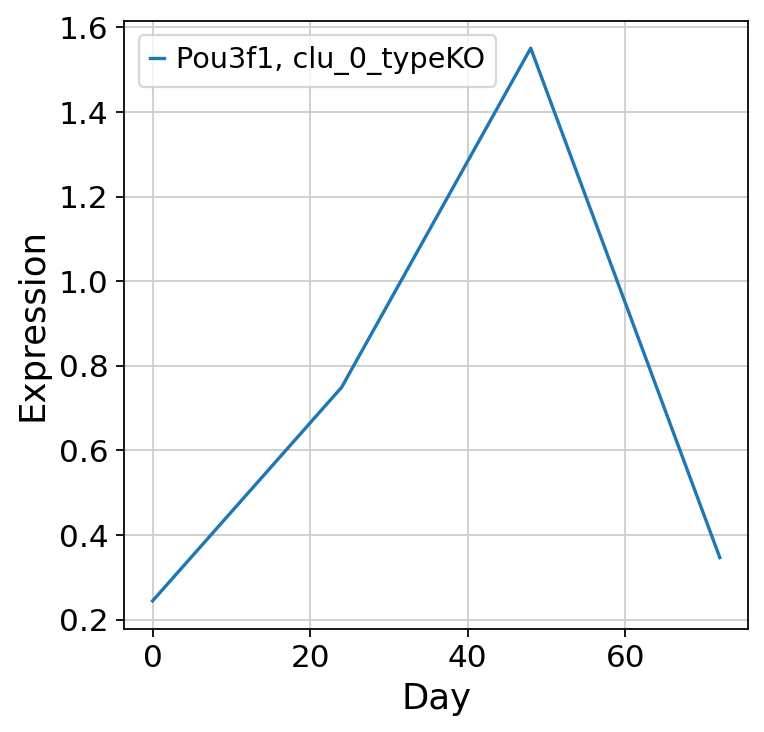

In [64]:
trajectory_dropdown = widgets.SelectMultiple(
    options=trajectory_ds.var.index,
    value=[trajectory_ds.var.index[0]],
    description='Trajectory:'
)

gene_input = widgets.Text(
    placeholder='',
    description='Genes:',
    value='Pou3f1',
    continuous_update=False
)

def update_trends_vis(selected_trajectories, gene_names):
    gene_names = gene_names.replace(' ', '').split(',')
    
    figure = plt.figure(figsize=(5, 5))
    
    
    for selected_trajectory in selected_trajectories:
        trajectory_index = trajectory_names.index(selected_trajectory)
        mean = trajectory_trend_datasets[trajectory_index]
        
  
        mean = mean[:, mean.var.index.str.lower().isin([gene.lower() for gene in gene_names])]
        timepoints = mean.obs.index.values.astype(float)
        mean.obs.index = mean.obs.index.astype('category')
    
        if mean.shape[1] > 0:
            for i in range(mean.shape[1]):  # each gene
                mean_i = mean[:, i].X
                plt.plot(timepoints, mean_i, label=mean.var.index[i] + ', ' + selected_trajectory)
            plt.xlabel("Day")
            plt.ylabel("Expression")
            plt.legend()

widgets.interact(update_trends_vis, selected_trajectories=trajectory_dropdown, gene_names=gene_input)

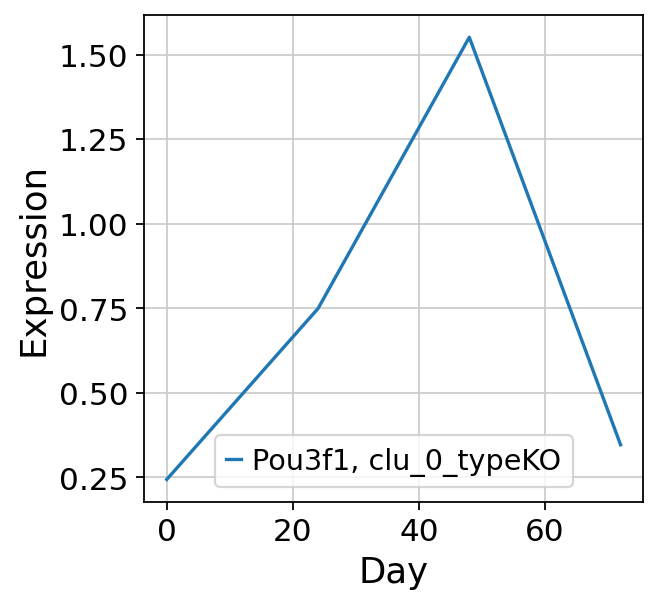

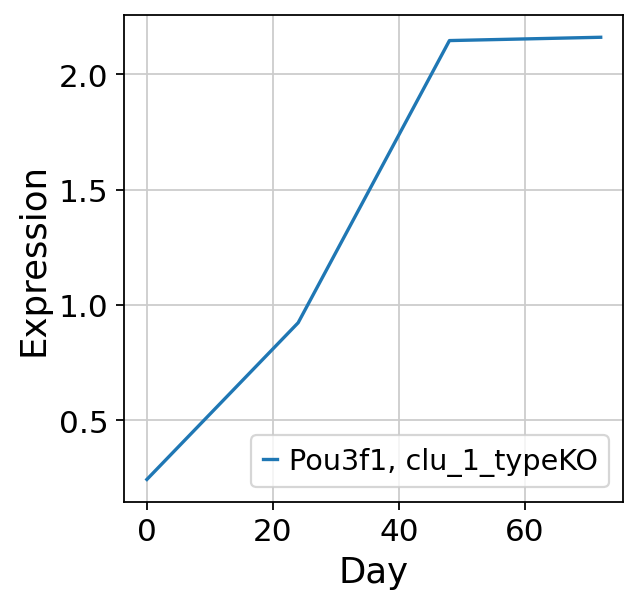

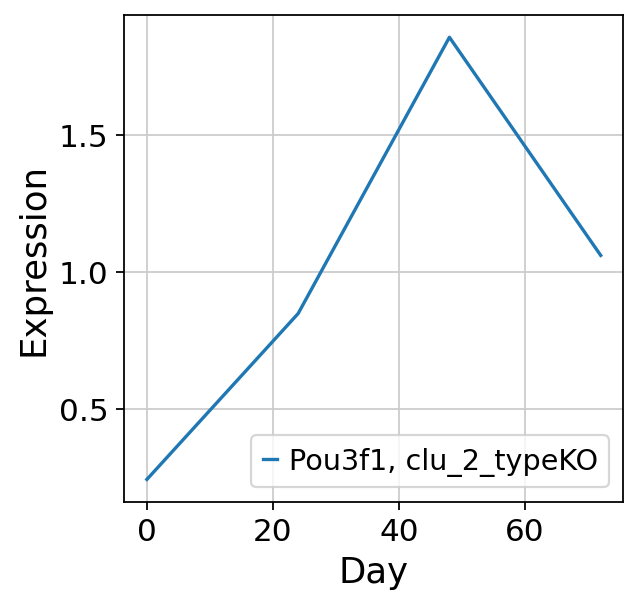

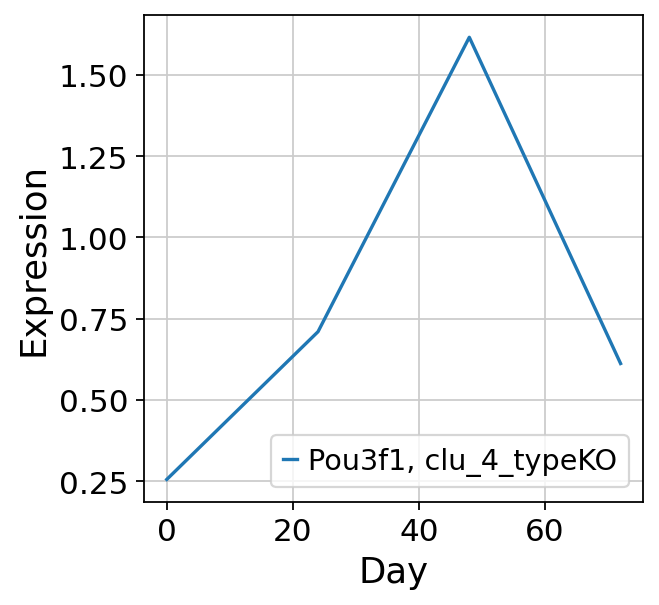

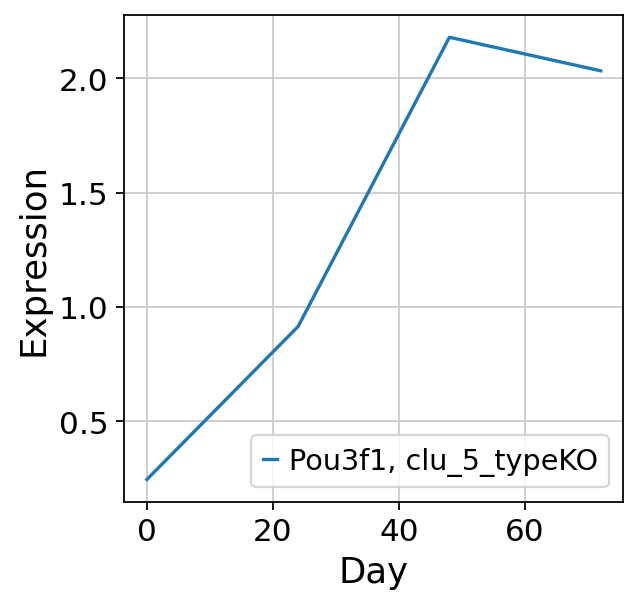

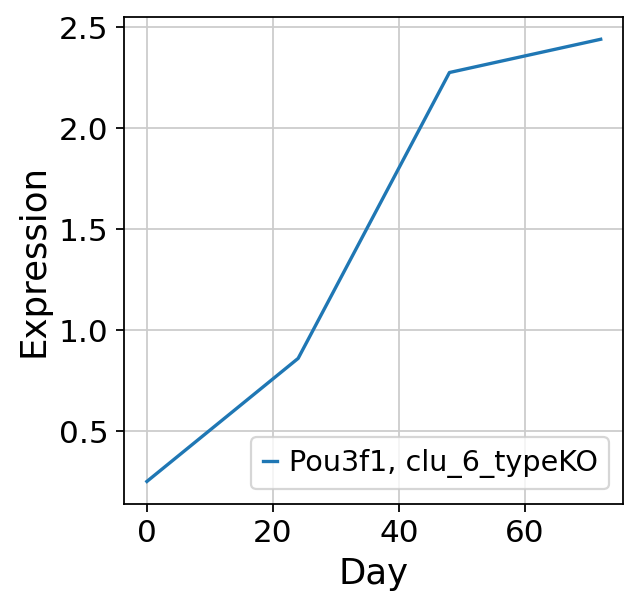

<Figure size 320x320 with 0 Axes>

In [77]:
gene_names = ['Pou3f1']
for selected_trajectory in trajectory_ds.var.index:
    trajectory_index = trajectory_names.index(selected_trajectory)
    mean = trajectory_trend_datasets[trajectory_index]


    mean = mean[:, mean.var.index.str.lower().isin([gene.lower() for gene in gene_names])]
    timepoints = mean.obs.index.values.astype(float)
    mean.obs.index = mean.obs.index.astype('category')

    if mean.shape[1] > 0:
        for i in range(mean.shape[1]):  # each gene
            mean_i = mean[:, i].X
            plt.plot(timepoints, mean_i, label=mean.var.index[i] + ', ' + selected_trajectory)
        plt.xlabel("Day")
        plt.ylabel("Expression")
        plt.legend()
        plt.show()
        plt.savefig('./figures/expression_' + gene_names[0] + '_' + selected_trajectory)

In [30]:
adata_wot.write('./data/adata_traj_ko.h5ad')
adata_var = wot.io.read_dataset('./data/adata_traj_ko.h5ad')

Divergence

In [31]:
divergence_df = wot.tmap.trajectory_divergence(adata_var, trajectory_ds, distance_metric='total_variation')

In [32]:
divergence_df.to_csv('./data/divergence_df_ko.csv')

In [33]:
#divergence_df = pd.read_csv('./data/divergence_df_wt.csv')

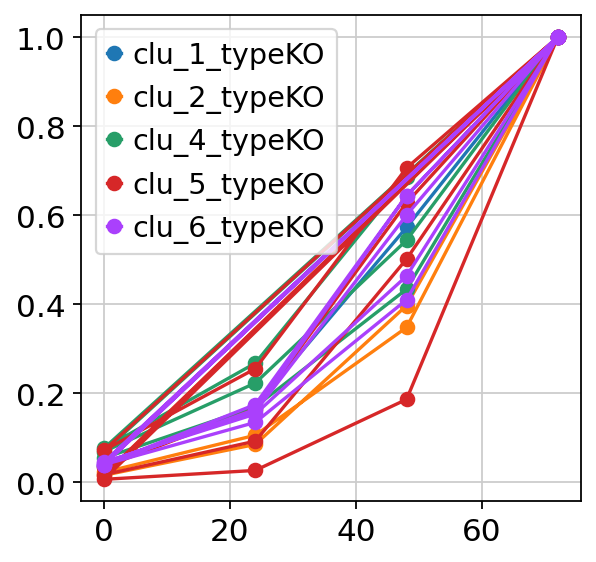

In [34]:
for p, d in divergence_df.groupby('name2'):
    plt.plot(d['day2'], d['distance'], '-o', label=p)
plt.legend(loc='best')

Fates

In [35]:
target_destinations = tmap_model.population_from_cell_sets(dicts, at_time= 72)

In [36]:
fate_ds = tmap_model.fates(target_destinations)

In [37]:
fate_ds.X.shape

(3321, 6)

In [38]:
df = pd.DataFrame(fate_ds.X, index = fate_ds.obs_names, columns = fate_ds.var_names)

In [39]:
df

,clu_0_typeKO,clu_1_typeKO,clu_2_typeKO,clu_4_typeKO,clu_5_typeKO,clu_6_typeKO
KO_0hrs_R1_AAACGAAGTGAGGATC-1,0.008633,0.165679,0.023668,0.028265,0.608350,0.165404
KO_0hrs_R1_AAAGAACCATAGTCAC-1,0.007320,0.159294,0.021658,0.028932,0.593821,0.188974
KO_0hrs_R1_AAAGTGATCTCTCGCA-1,0.007743,0.157551,0.021567,0.032243,0.591250,0.189645
KO_0hrs_R1_AAATGGACATAAGCAA-1,0.008031,0.161428,0.022748,0.032305,0.595835,0.179653
KO_0hrs_R1_AACAACCTCGTGGCGT-1,0.007871,0.158786,0.022156,0.031258,0.593638,0.186291
...,...,...,...,...,...,...
KO_72hrs_R2_TGGCGTGCAATGCTCA-1,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
KO_72hrs_R2_TGTGGCGGTCCCACGA-1,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
KO_72hrs_R2_TTCATTGTCCAACCGG-1,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
KO_72hrs_R2_TTCCGGTCATTGGCAT-1,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


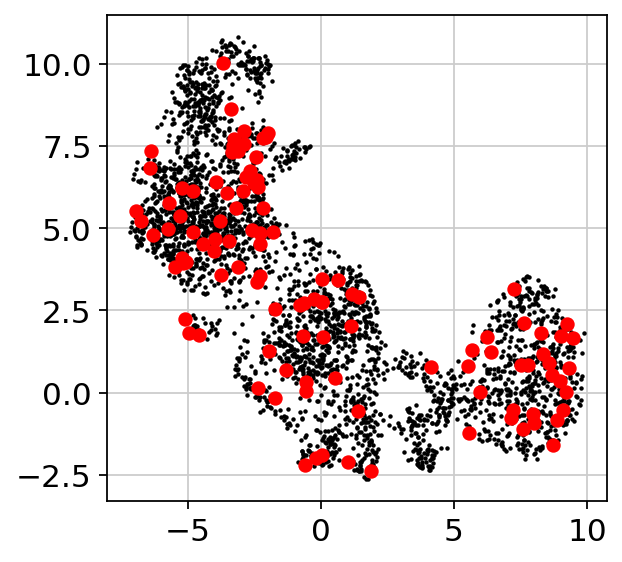

In [40]:
thr = 0.8
vec_ko = np.array((df['clu_6_typeKO']>thr))

plt.scatter(adata_wot.obs.x, adata_wot.obs.y,s = 1,c = 'k')
plt.scatter(adata_wot[vec_ko,:].obs.x, adata_wot[vec_ko,:].obs.y,s = 30,c = 'r')

interactive(children=(Dropdown(description='Fate 1:', options=('clu_0_typeKO', 'clu_1_typeKO', 'clu_2_typeKO',…

<function __main__.update_fate_vis(name1, name2, day)>

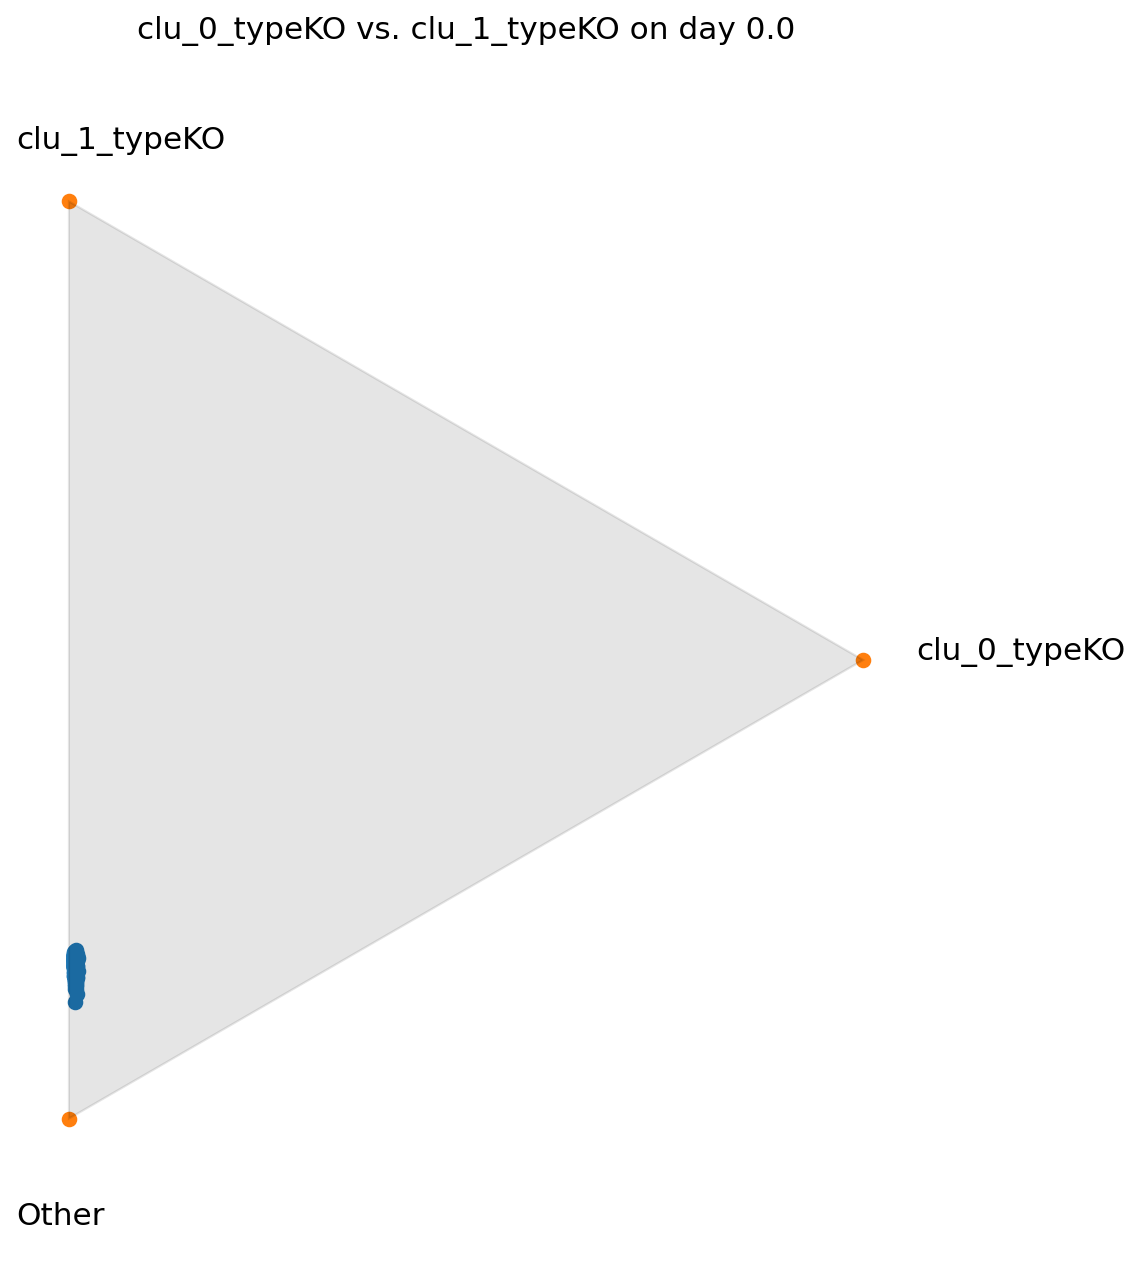

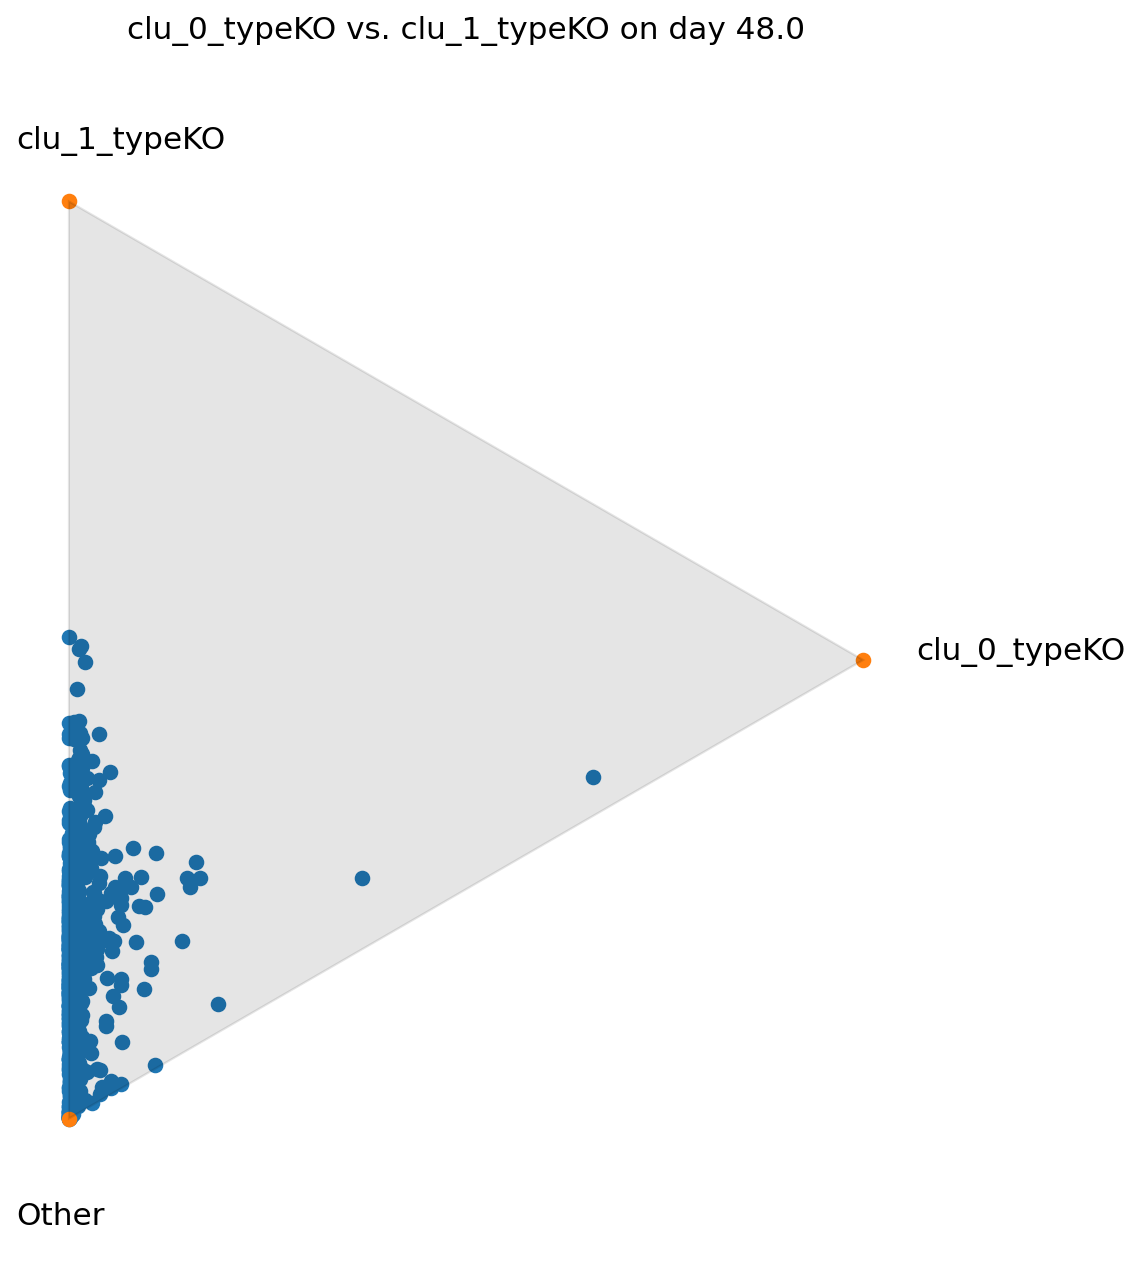

In [41]:
fate_dropdown1 = widgets.Dropdown(
    options=fate_ds.var.index,
    description='Fate 1:'
)
fate_dropdown2 = widgets.Dropdown(
    options=fate_ds.var.index,
    description='Fate 2:',
    value=fate_ds.var.index[1]
)
day_dropdown = widgets.Dropdown(
    options=fate_ds.obs['day'].unique(),
    description='Day',
    value=0
)


def update_fate_vis(name1, name2,day):
    figure = plt.figure(figsize=(7, 10))   

    fate1 = fate_ds[:,name1][fate_ds.obs['day']==day].X.flatten()
    fate2 = fate_ds[:,name2][fate_ds.obs['day']==day].X.flatten()

    Nrows = len(fate1)
    x = np.zeros(Nrows)
    y = np.zeros(Nrows)
    P = np.array([[1,0],[np.cos(2*math.pi/3),math.sin(2*math.pi/3)],[math.cos(4*math.pi/3),math.sin(4*math.pi/3)]])

    for i in range(0,Nrows):
        ff = np.array([fate1[i],fate2[i],1-(fate1[i]+fate2[i])])
        x[i] = (ff @ P)[0]
        y[i] = (ff @ P)[1]

    vx = P[:,0]
    vy = P[:,1]
    t1 = plt.Polygon(P, color=(0,0,0,0.1))
    plt.gca().add_patch(t1)
    
    plt.scatter(x,y)
    plt.scatter(vx,vy)
    #plt.scatter(0,0)
    plt.text(P[0,0]+.1, P[0,1], name1)
    plt.text(P[1,0]-.1, P[1,1]+.1, name2)
    plt.text(P[2,0]-.1, P[2,1]-.2, 'Other')
    plt.axis('equal')
    plt.axis('off')
    #plt.xticks([])
    #plt.yticks([])
    
    plt.title('{} vs. {} on day {}'.format(name1, name2,day))

widgets.interact(update_fate_vis, name1=fate_dropdown1, name2=fate_dropdown2,day=day_dropdown)

Logodds

interactive(children=(Dropdown(description='Fate 1:', options=('clu_0_typeKO', 'clu_1_typeKO', 'clu_2_typeKO',…

<function __main__.update_fate_vis(name1, name2)>

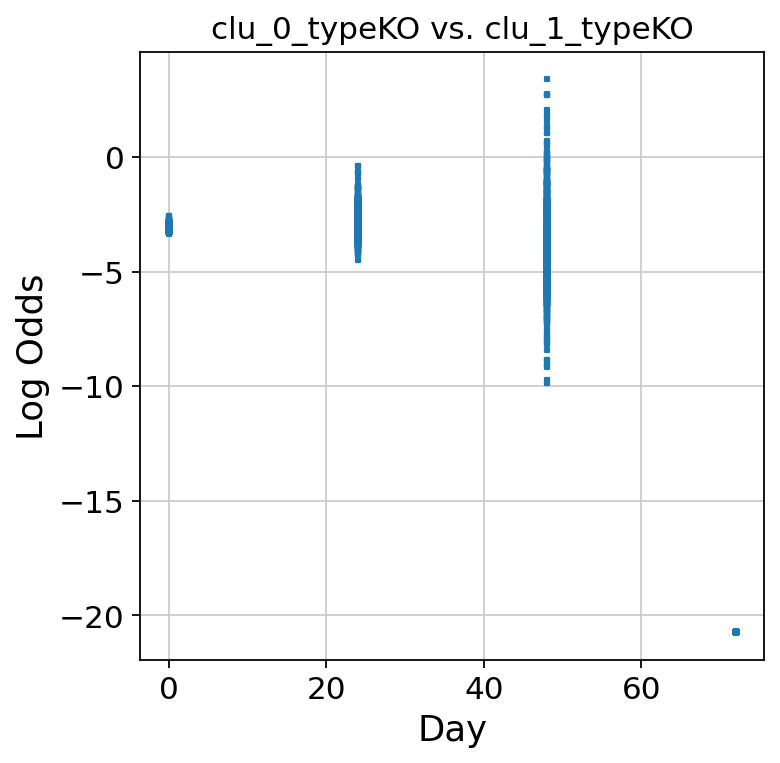

In [42]:
fate_dropdown1 = widgets.Dropdown(
    options=fate_ds.var.index,
    description='Fate 1:'
)
fate_dropdown2 = widgets.Dropdown(
    options=fate_ds.var.index,
    description='Fate 2:',
    value=fate_ds.var.index[1]
)

def update_fate_vis(name1, name2):
    figure = plt.figure(figsize=(5,5))
    fate1 = fate_ds[:, name1].X
    fate2 = fate_ds[:, name2].X
    p = np.log(1e-9 + np.divide(fate1, fate2, out=np.zeros_like(fate1), where=fate2 != 0))
    plt.scatter(fate_ds.obs['day'], p, s=4, marker=',')
    plt.xlabel('Day')
    plt.ylabel('Log Odds')
    plt.title('{} vs. {}'.format(name1, name2))

widgets.interact(update_fate_vis, name1=fate_dropdown1, name2=fate_dropdown2)

Transition table

In [43]:
start_populations = tmap_model.population_from_cell_sets(dicts, at_time=0)
end_populations = tmap_model.population_from_cell_sets(dicts, at_time=24)

In [44]:
transition_table = tmap_model.transition_table(start_populations, end_populations)

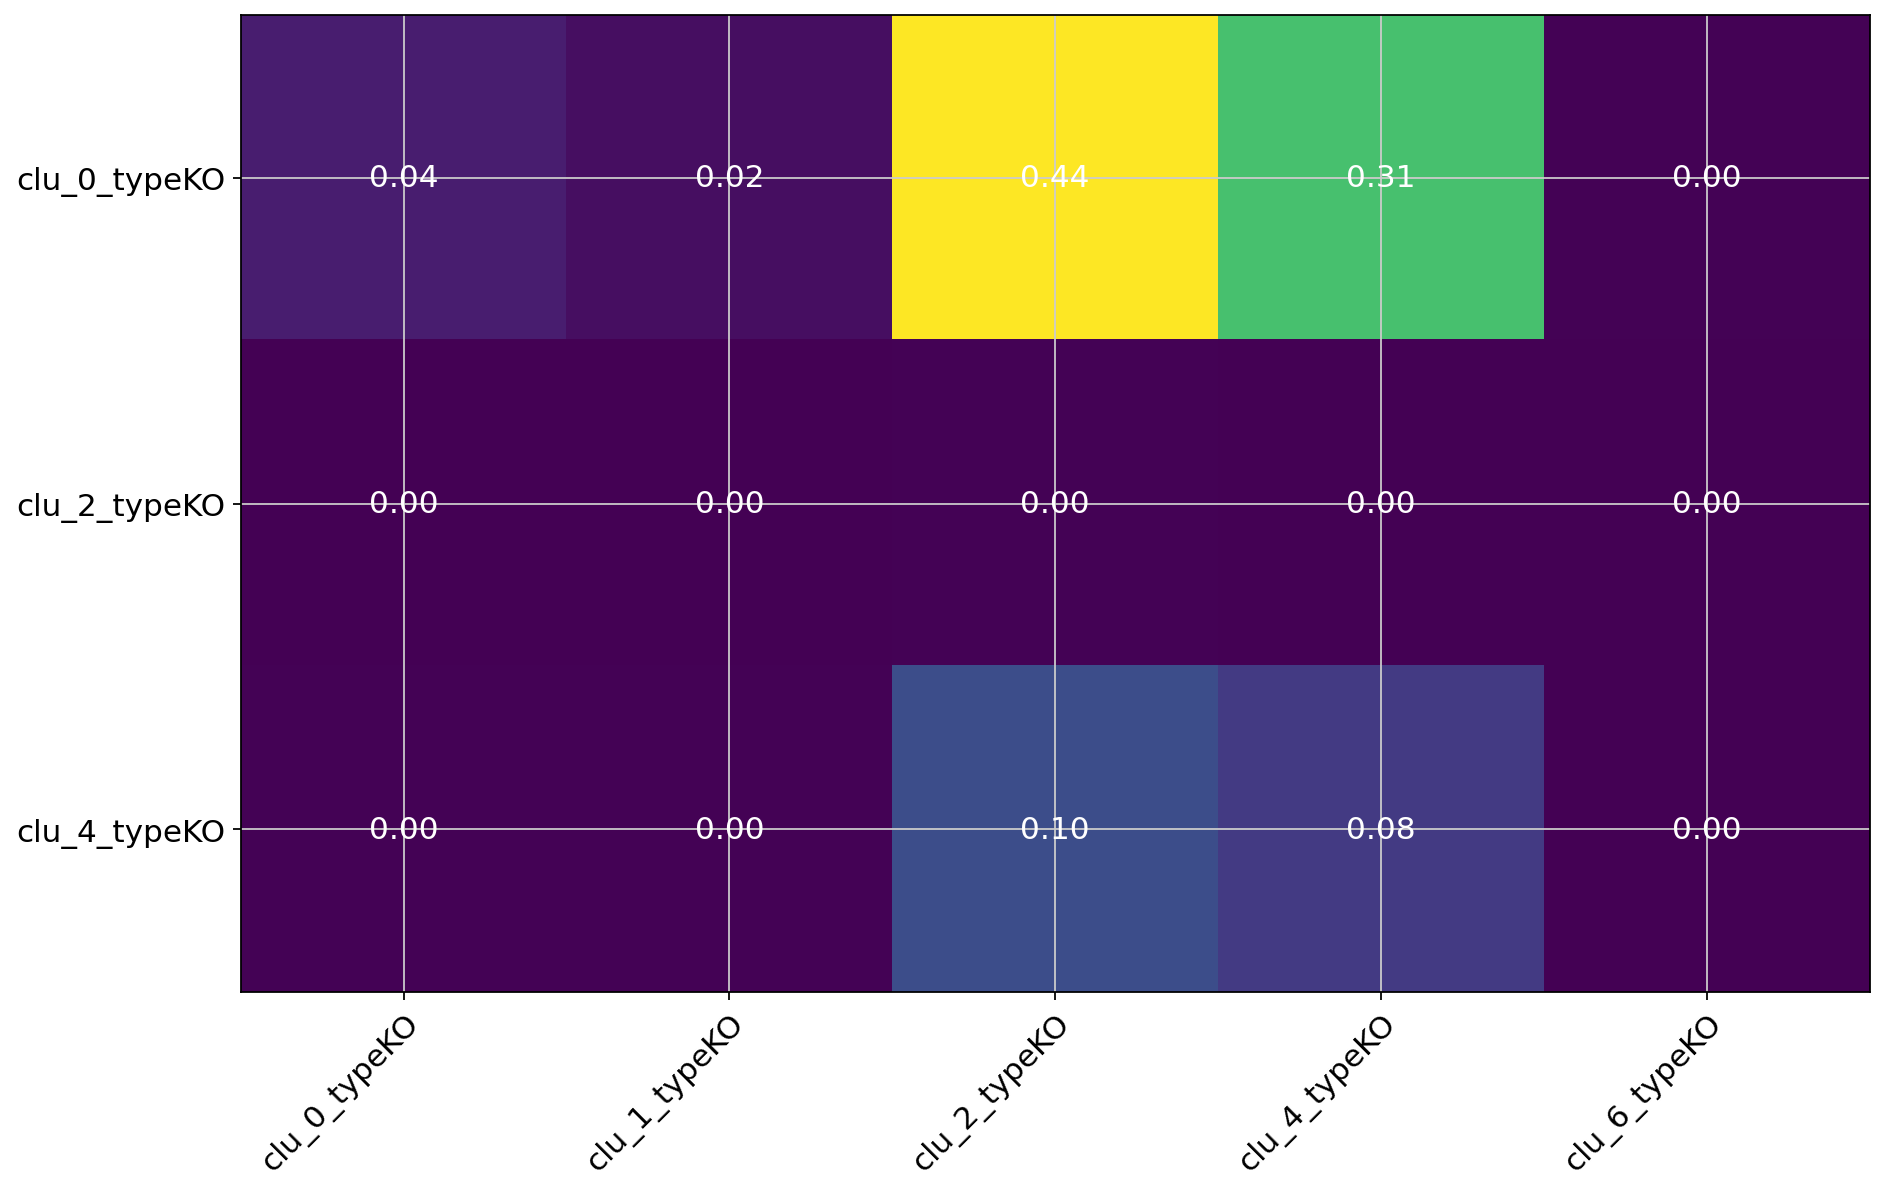

In [45]:
fig, ax = plt.subplots(figsize=(12, 12))
im = ax.imshow(transition_table.X)

# We want to show all ticks...
ax.set_xticks(np.arange(len(transition_table.var_names)))
ax.set_yticks(np.arange(len(transition_table.obs_names)))
# ... and label them with the respective list entries
ax.set_xticklabels(transition_table.var_names)
ax.set_yticklabels(transition_table.obs_names)

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

# Loop over data dimensions and create text annotations.
for i in range(transition_table.shape[0]):
    for j in range(transition_table.shape[1]):
        text = ax.text(j, i, '{:.2f}'.format(transition_table.X[i, j]),
                       ha="center", va="center", color="w")
fig.tight_layout()